## Setup

In [ ]:
#| default_exp hyper_account

In [ ]:
#|hide
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from token_data.hyperliquid import *
from hyperliquid.utils import constants
import pandas as pd
import numpy as np

In [ ]:
address, info, exchange = setup(base_url=constants.MAINNET_API_URL, skip_ws=True)

Running with account address: 0x143E18B563C4aD6913a9D89C774fE69A54F66cAa
Running with agent address: 0x0486f56Bf31b2E3B880248dAcd1BFf3C8bdC09e0


## get_user_fills function

Function to list all trades and fills for a given account.

In [ ]:
#| export
def get_user_fills(address, info=None, aggregated=False, include_hash_oid=False):
    """
    Retrieves user fill history from Hyperliquid and returns as a DataFrame.
    
    Args:
        address (str): User's wallet address
        info (Info, optional): Hyperliquid Info client. If None, creates a new one.
        aggregated (bool, optional): If True, returns aggregated fills. Defaults to False.
    
    Returns:
        pandas.DataFrame: DataFrame containing fill data indexed by datetime with columns:
            - coin: Trading pair/coin
            - px: Fill price
            - sz: Fill size
            - side: Trade side (A for ask/sell, B for bid/buy)
            - time: Original timestamp in milliseconds
            - startPosition: Position size before fill
            - dir: Direction of trade
            - closedPnl: Realized PnL from closing position
            - hash: Transaction hash
            - oid: Order ID
            - crossed: Whether order crossed the spread
            - fee: Trading fee paid
            - tid: Trade ID
            - feeToken: Token used for fee payment
        Returns None if no fills found or error occurs.
    
    Examples:
        # Get all user fills
        fills_df = get_user_fills(address, info=info)
        
        # Get aggregated fills
        fills_df = get_user_fills(address, info=info, aggregated=True)
        
        # Filter for specific coin
        eth_fills = fills_df[fills_df['coin'] == 'ETH']
        
        # Calculate total fees paid
        total_fees = fills_df['fee'].sum()
    
    Notes:
        - DataFrame is indexed by datetime (converted from milliseconds)
        - All numeric columns are converted to float for calculations
        - Sorted by datetime in ascending order
    """
    # Initialize info client if not provided
    if info is None:
        from hyperliquid.info import Info
        from hyperliquid.utils import constants
        address_temp, info, exchange = setup(base_url=constants.MAINNET_API_URL, skip_ws=True)
    
    try:
        # Get user fills
        if aggregated:
            user_fills = info.user_fills(address, aggregated=True)
        else:
            user_fills = info.user_fills(address)
        
        if not user_fills:
            print("No fills found for this address")
            return None
        
        # Convert to DataFrame
        fills_df = pd.DataFrame(user_fills)
        
        # Convert timestamp to datetime
        fills_df['datetime'] = pd.to_datetime(fills_df['time'], unit='ms')
        
        # Convert numeric columns to float
        numeric_cols = ['px', 'sz', 'startPosition', 'closedPnl', 'fee']
        for col in numeric_cols:
            if col in fills_df.columns:
                fills_df[col] = fills_df[col].astype(float)
        
        # Set datetime as index
        fills_df = fills_df.set_index('datetime')
        
        # Sort by datetime
        fills_df = fills_df.sort_index()
        
        # Add human-readable side column
        if 'side' in fills_df.columns:
            fills_df['side_readable'] = fills_df['side'].map({'A': 'Sell', 'B': 'Buy'})
        
        fills_df['fee_usdc'] = fills_df.apply(
            lambda row: row['fee'] * row['px'] if row['feeToken'] != 'USDC' else row['fee'],
            axis=1
        )
        # Calculate fee in basis points (bps)
        # Fee in bps = (fee / (price * size)) * 10000
        fills_df['fee_bps'] = (fills_df['fee_usdc'] / (fills_df['px'] * fills_df['sz'])) * 10000

        # Drop hash and oid columns if not requested
        if not include_hash_oid:
            cols_to_drop = [col for col in ['hash', 'oid','tid','time'] if col in fills_df.columns]
            if cols_to_drop:
                fills_df = fills_df.drop(columns=cols_to_drop)

        return fills_df
        
    except Exception as e:
        print(f"Error retrieving user fills: {e}")
        return None

In [ ]:
#| eval:false

fills_df = get_user_fills(address, info=info)

if fills_df is not None:
    print(f"Total Fills: {len(fills_df)}")
    print(f"\nFills Summary:")
    print(f"Date Range: {fills_df.index.min()} to {fills_df.index.max()}")
    print(f"\nFills by Coin:")
    print(fills_df.groupby('coin').size().sort_values(ascending=False))
    print(f"\nTotal Fees Paid: ${fills_df['fee'].sum():.2f}")
    print(f"Total Closed PnL: ${fills_df['closedPnl'].sum():.2f}")

Total Fills: 4

Fills Summary:
Date Range: 2025-09-13 13:41:44.333000 to 2025-10-21 00:52:28.595000

Fills by Coin:
coin
@151    2
ETH     2
dtype: int64

Total Fees Paid: $0.01
Total Closed PnL: $0.00


In [ ]:
#| eval:false
print(fills_df)

                         coin      px      sz side  startPosition         dir  \
datetime                                                                        
2025-09-13 13:41:44.333  @151  4716.2  0.0025    B       0.000000         Buy   
2025-09-13 13:45:17.196   ETH  4713.5  0.0023    A       0.000000  Open Short   
2025-10-21 00:51:35.312  @151  3974.8  0.0030    B       0.002498         Buy   
2025-10-21 00:52:28.595   ETH  3972.2  0.0030    A      -0.002300  Open Short   

                         closedPnl  crossed       fee feeToken twapId  \
datetime                                                                
2025-09-13 13:41:44.333        0.0     True  0.000002     UETH   None   
2025-09-13 13:45:17.196        0.0    False  0.001626     USDC   None   
2025-10-21 00:51:35.312        0.0     True  0.000002     UETH   None   
2025-10-21 00:52:28.595        0.0     True  0.005362     USDC   None   

                        side_readable  fee_usdc   fee_bps  
datetime      

## get_user_funding_history function

Function to retrieve funding rate history for a personal account. This is what your account is paying or receiving in USDC per hour.

In [ ]:

#| export
def get_user_funding_history(address, start_date=None, end_date=None, lookback=30, info=None,include_hash_time=False):
    """
    Retrieves user funding payment history from Hyperliquid and returns as a DataFrame.
    
    Args:
        address (str): User's wallet address
        start_date (str, optional): Start date as string. Can be:
            - ISO format: "2024-01-15T10:30:00Z" or "2024-01-15T10:30:00"
            - Date only: "2024-01-15"
            - If None, calculated from lookback. Defaults to None.
        end_date (str, optional): End date as string (same formats as start_date).
            - If None, uses current UTC time. Defaults to None.
        lookback (int, optional): Number of days to look back from end_date if start_date is None.
            Defaults to 30.
        info (Info, optional): Hyperliquid Info client. If None, creates a new one.
    
    Returns:
        pandas.DataFrame: DataFrame containing funding payment data indexed by datetime with columns:
            - coin: Trading pair/coin
            - usdc: Funding payment amount in USDC (positive = received, negative = paid)
            - time: Original timestamp in milliseconds
        Returns None if no funding payments found or error occurs.
    
    Examples:
        # Get last 30 days of funding payments
        funding_df = get_user_funding_history(address, info=info)
        
        # Get funding for specific date range
        funding_df = get_user_funding_history(address, 
                                             start_date="2024-01-01",
                                             end_date="2024-01-31",
                                             info=info)
        
        # Calculate total funding received/paid
        total_funding = funding_df['usdc'].sum()
        
        # Get funding by coin
        funding_by_coin = funding_df.groupby('coin')['usdc'].sum()
    
    Notes:
        - DataFrame is indexed by datetime (converted from milliseconds)
        - Positive usdc values indicate funding received
        - Negative usdc values indicate funding paid
        - All numeric columns are converted to float for calculations
        - Sorted by datetime in ascending order
    """
    # Initialize info client if not provided
    if info is None:
        from hyperliquid.info import Info
        from hyperliquid.utils import constants
        address_temp, info, exchange = setup(base_url=constants.MAINNET_API_URL, skip_ws=True)
    
    # Handle end_date
    if end_date is None:
        end_dt = pd.Timestamp.now(tz='UTC')
    else:
        try:
            end_dt = pd.to_datetime(end_date)
        except Exception as e:
            print(f"Error parsing end_date '{end_date}': {e}")
            return None

    # Handle start_date
    if start_date is None:
        start_dt = end_dt - pd.Timedelta(days=lookback)
    else:
        try:
            start_dt = pd.to_datetime(start_date)
        except Exception as e:
            print(f"Error parsing start_date '{start_date}': {e}")
            return None
    
    # Convert to Unix milliseconds timestamps
    start_time_ms = int(start_dt.timestamp() * 1000)
    end_time_ms = int(end_dt.timestamp() * 1000)
    
    try:
        # Get user funding history
        funding_history = info.user_funding_history(address, start_time_ms, end_time_ms)
        
        if not funding_history:
            print("No funding payments found for this address in the specified period")
            return None
        
        # Flatten the nested dictionary structure
        flattened_data = []
        for record in funding_history:
            flat_record = {
                'time': record['time'],
                'hash': record['hash'],
                'coin': record['delta']['coin'],
                'usdc': float(record['delta']['usdc']),
                'szi': float(record['delta']['szi']),
                'fundingRate': float(record['delta']['fundingRate'])
            }
            flattened_data.append(flat_record)
        
        # Convert to DataFrame
        funding_df = pd.DataFrame(flattened_data)
        
        # Convert timestamp to datetime
        funding_df['datetime'] = pd.to_datetime(funding_df['time'], unit='ms')
        
        # Convert numeric columns to float
        numeric_cols = ['usdc', 'delta']
        for col in numeric_cols:
            if col in funding_df.columns:
                funding_df[col] = funding_df[col].astype(float)
        
        # Set datetime as index
        funding_df = funding_df.set_index('datetime')
        
        # Sort by datetime
        funding_df = funding_df.sort_index()
        
        # Drop hash and time columns if not requested
        if not include_hash_time:
            cols_to_drop = [col for col in ['hash', 'time'] if col in funding_df.columns]
            if cols_to_drop:
                funding_df = funding_df.drop(columns=cols_to_drop)
        
        return funding_df
        
    except Exception as e:
        print(f"Error retrieving user funding history: {e}")
        return None

In [ ]:
#| eval:false
# Get last 30 days of funding payments
funding_df = get_user_funding_history(address, lookback=90, info=info)

if funding_df is not None:
    print(f"Total Funding Records: {len(funding_df)}")
    print(f"\nDate Range: {funding_df.index.min()} to {funding_df.index.max()}")
    
    print(f"\nFunding Summary by Coin:")
    summary = funding_df.groupby('coin')['usdc'].agg(['sum', 'count', 'mean'])
    summary.columns = ['Total USDC', 'Count', 'Avg Payment']
    print(summary)
    

Total Funding Records: 500

Date Range: 2025-09-13 00:00:00 to 2025-11-01 13:00:00.047000

Funding Summary by Coin:
      Total USDC  Count  Avg Payment
coin                                
ETH     0.132697    500     0.000265


In [ ]:
#|eval:false
print(f"\nTotal Funding Received/Paid: ${funding_df['usdc'].sum():.2f}")
print(f"\nRecent Funding Payments:")
print(funding_df)


Total Funding Received/Paid: $0.13

Recent Funding Payments:
                        coin      usdc     szi   fundingRate
datetime                                                    
2025-09-13 00:00:00.000  ETH  0.001983 -0.0023  1.860820e-05
2025-09-14 00:00:00.000  ETH  0.004339 -0.0023  1.697070e-05
2025-09-15 00:00:00.000  ETH  0.003951 -0.0023  1.573280e-05
2025-09-16 00:00:00.000  ETH  0.003097 -0.0023  1.252500e-05
2025-09-17 00:00:00.000  ETH  0.003098 -0.0023  1.250000e-05
...                      ...       ...     ...           ...
2025-11-01 09:00:00.075  ETH  0.000087 -0.0053  4.272600e-06
2025-11-01 10:00:00.010  ETH  0.000009 -0.0053  4.400000e-07
2025-11-01 11:00:00.062  ETH  0.000051 -0.0053  2.511500e-06
2025-11-01 12:00:00.072  ETH  0.000140 -0.0053  6.840700e-06
2025-11-01 13:00:00.047  ETH  0.000124 -0.0053  6.043900e-06

[500 rows x 4 columns]


<Axes: title={'center': 'ETH Funding Payments'}, xlabel='datetime'>

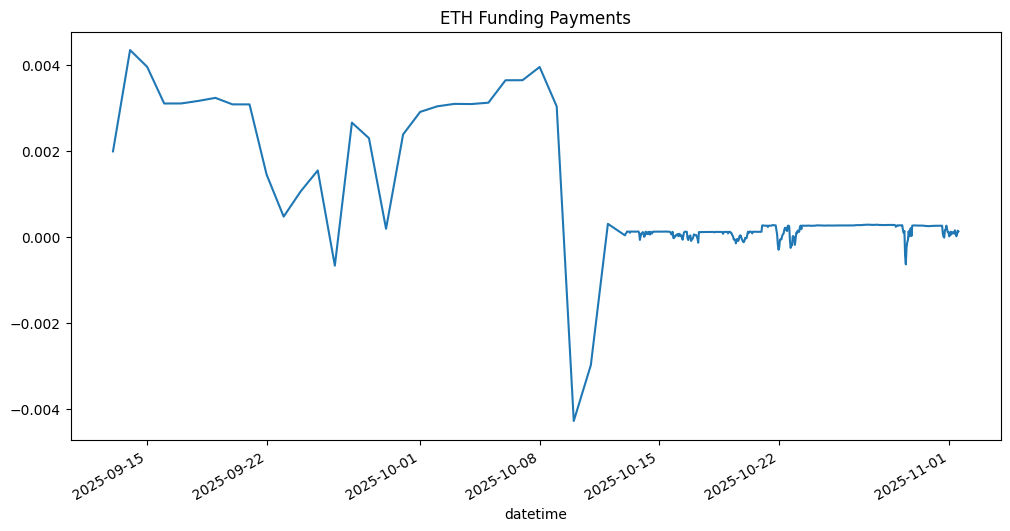

In [ ]:
#|eval:false
funding_df[funding_df['coin'] == 'ETH']['usdc'].plot(figsize=(12, 6), title="ETH Funding Payments")

<Axes: title={'center': 'ETH Funding Rate'}, xlabel='datetime'>

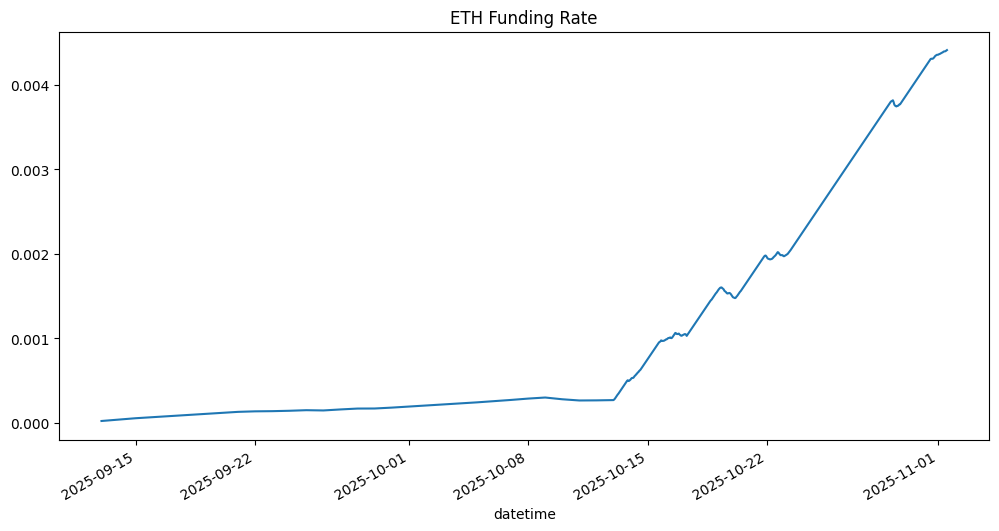

In [ ]:
#| eval:false
funding_df[funding_df['coin'] == 'ETH']['fundingRate'].cumsum().plot(figsize=(12, 6), title="ETH Funding Rate")

<Axes: title={'center': 'Cumsum Funding Received/Paid'}, xlabel='datetime'>

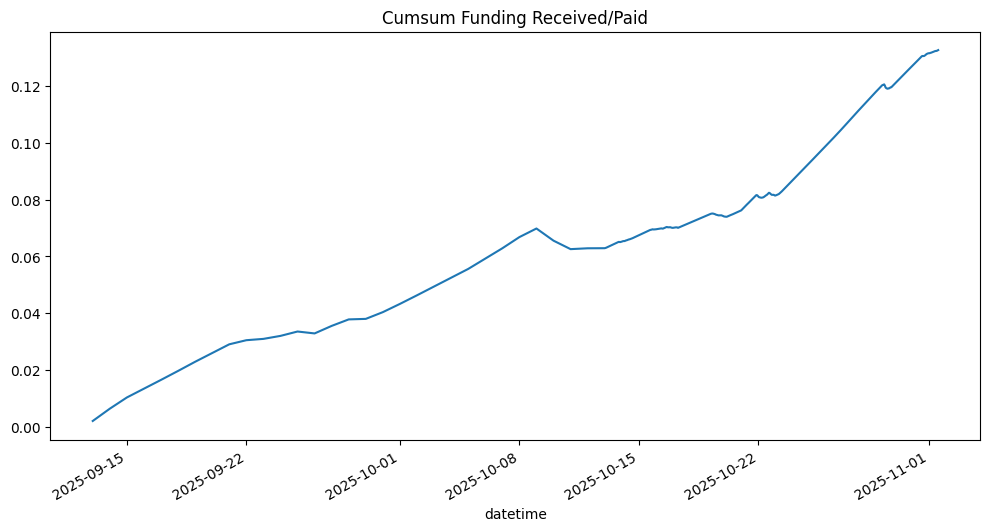

In [ ]:
#| eval:false
funding_df[funding_df['coin'] == 'ETH']['usdc'].cumsum().plot(figsize=(12, 6), title="Cumsum Funding Received/Paid")

## get_user_ledger_updates function


In [ ]:
#| export
def get_user_ledger_updates(address, start_date=None, end_date=None, lookback=30, info=None, include_hash=False):
    """
    Retrieves user non-funding ledger updates from Hyperliquid and returns as a DataFrame.
    
    This function captures account events like deposits, withdrawals, transfers, and other
    non-funding related balance changes.
    
    Args:
        address (str): User's wallet address
        start_date (str, optional): Start date as string. Can be:
            - ISO format: "2024-01-15T10:30:00Z" or "2024-01-15T10:30:00"
            - Date only: "2024-01-15"
            - If None, calculated from lookback. Defaults to None.
        end_date (str, optional): End date as string (same formats as start_date).
            - If None, uses current UTC time. Defaults to None.
        lookback (int, optional): Number of days to look back from end_date if start_date is None.
            Defaults to 30.
        info (Info, optional): Hyperliquid Info client. If None, creates a new one.
        include_hash (bool, optional): If True, includes 'hash' column with transaction hashes.
            Defaults to False.
    
    Returns:
        pandas.DataFrame: DataFrame containing ledger update data indexed by datetime with columns:
            - type: Type of ledger update (e.g., 'deposit', 'withdraw', 'accountClassTransfer')
            - usdc: Amount in USDC
            - toPerp: For transfers, whether transfer was to perpetual account (True) or from (False)
            - hash: Transaction hash (only if include_hash=True)
        Returns None if no ledger updates found or error occurs.
    
    Examples:
        # Get last 30 days of ledger updates
        ledger_df = get_user_ledger_updates(address, info=info)
        
        # Get ledger updates for specific date range
        ledger_df = get_user_ledger_updates(address, 
                                           start_date="2024-01-01",
                                           end_date="2024-01-31",
                                           info=info)
        
        # Calculate total deposits
        deposits = ledger_df[ledger_df['type'] == 'deposit']['usdc'].sum()
        
        # Calculate total withdrawals
        withdrawals = ledger_df[ledger_df['type'] == 'withdraw']['usdc'].sum()
        
        # Get all transfers to perpetual account
        to_perp = ledger_df[(ledger_df['type'] == 'accountClassTransfer') & 
                           (ledger_df['toPerp'] == True)]
    
    Notes:
        - DataFrame is indexed by datetime (converted from milliseconds)
        - All numeric columns are converted to float for calculations
        - Sorted by datetime in ascending order
        - Does not include funding payments (use get_user_funding_history for that)
        - Common transaction types:
            * 'deposit': Deposits to account
            * 'withdraw': Withdrawals from account
            * 'accountClassTransfer': Transfers between spot and perpetual accounts
    """
    # Initialize info client if not provided
    if info is None:
        from hyperliquid.info import Info
        from hyperliquid.utils import constants
        address_temp, info, exchange = setup(base_url=constants.MAINNET_API_URL, skip_ws=True)
    
    # Handle end_date
    if end_date is None:
        end_dt = pd.Timestamp.now(tz='UTC')
    else:
        try:
            end_dt = pd.to_datetime(end_date)
        except Exception as e:
            print(f"Error parsing end_date '{end_date}': {e}")
            return None

    # Handle start_date
    if start_date is None:
        start_dt = end_dt - pd.Timedelta(days=lookback)
    else:
        try:
            start_dt = pd.to_datetime(start_date)
        except Exception as e:
            print(f"Error parsing start_date '{start_date}': {e}")
            return None
    
    # Convert to Unix milliseconds timestamps
    start_time_ms = int(start_dt.timestamp() * 1000)
    end_time_ms = int(end_dt.timestamp() * 1000)
    
    try:
        # Get user non-funding ledger updates
        ledger_updates = info.user_non_funding_ledger_updates(address, start_time_ms, end_time_ms)
        
        if not ledger_updates:
            print("No ledger updates found for this address in the specified period")
            return None
        
        # Flatten the nested dictionary structure
        flattened_data = []
        for record in ledger_updates:
            flat_record = {
                'time': record['time'],
                'hash': record['hash'],
                'type': record['delta']['type'],
                'usdc': float(record['delta']['usdc'])
            }
            
            # Add toPerp field if it exists (for accountClassTransfer)
            if 'toPerp' in record['delta']:
                flat_record['toPerp'] = record['delta']['toPerp']
            else:
                flat_record['toPerp'] = None
            
            flattened_data.append(flat_record)
        
        # Convert to DataFrame
        ledger_df = pd.DataFrame(flattened_data)
        
        # Convert timestamp to datetime
        ledger_df['datetime'] = pd.to_datetime(ledger_df['time'], unit='ms')
        
        # Set datetime as index
        ledger_df = ledger_df.set_index('datetime')
        
        # Sort by datetime
        ledger_df = ledger_df.sort_index()
        
        # Drop time column (we have datetime as index)
        ledger_df = ledger_df.drop(columns=['time'])
        
        # Drop hash column if not requested
        if not include_hash:
            ledger_df = ledger_df.drop(columns=['hash'])
        
        return ledger_df
        
    except Exception as e:
        print(f"Error retrieving user ledger updates: {e}")
        return None

In [ ]:
#| eval:false
# Test the function
ledger_df = get_user_ledger_updates(address, info=info, lookback=90)

if ledger_df is not None:
    print(f"Total Ledger Updates: {len(ledger_df)}")
    print(f"\nDate Range: {ledger_df.index.min()} to {ledger_df.index.max()}")
    
    print(f"\nLedger Updates by Type:")
    print(ledger_df.groupby('type').size().sort_values(ascending=False))
    
    print(f"\nSummary by Type:")
    summary = ledger_df.groupby('type')['usdc'].agg(['sum', 'count', 'mean'])
    summary.columns = ['Total USDC', 'Count', 'Avg Amount']
    print(summary)
    
    # Calculate net deposits/withdrawals
    deposits = ledger_df[ledger_df['type'] == 'deposit']['usdc'].sum()
    withdrawals = ledger_df[ledger_df['type'] == 'withdraw']['usdc'].sum()
    print(f"\nTotal Deposits: ${deposits:.2f}")
    print(f"Total Withdrawals: ${withdrawals:.2f}")
    print(f"Net Deposits: ${deposits - withdrawals:.2f}")
    
    # Show transfers between accounts
    transfers = ledger_df[ledger_df['type'] == 'accountClassTransfer']
    if len(transfers) > 0:
        to_perp = transfers[transfers['toPerp'] == True]['usdc'].sum()
        from_perp = transfers[transfers['toPerp'] == False]['usdc'].sum()
        print(f"\nTransfers to Perpetual: ${to_perp:.2f}")
        print(f"Transfers from Perpetual: ${from_perp:.2f}")

Total Ledger Updates: 5

Date Range: 2025-09-13 13:29:51.820000 to 2025-11-01 13:08:31.024000

Ledger Updates by Type:
type
deposit                 3
accountClassTransfer    2
dtype: int64

Summary by Type:
                      Total USDC  Count  Avg Amount
type                                               
accountClassTransfer       35.00      2       17.50
deposit                    91.26      3       30.42

Total Deposits: $91.26
Total Withdrawals: $0.00
Net Deposits: $91.26

Transfers to Perpetual: $0.00
Transfers from Perpetual: $35.00


Deposit and transfers between perp and spot accounts has been checked against Hyperliquid "Portfolio" page. Values are consistent with the Hyperliquid Portfolio page.

In [ ]:
#| eval:false
ledger_df

,type,usdc,toPerp
datetime,,,
2025-09-13 13:29:51.820,deposit,30.00,None
2025-09-13 13:31:44.867,accountClassTransfer,15.00,False
2025-10-21 00:41:50.464,deposit,31.90,None
2025-10-21 00:45:18.649,accountClassTransfer,20.00,False
2025-11-01 13:08:31.024,deposit,29.36,None


In [ ]:
#[method for method in dir(info) if 'user' in method.lower()]

In [ ]:
#| eval:false
# Check the help documentation for user_fees
#help(info.user_fees)
#help(info.user_state)

## get_account_summary function

In order to validate these results, you can use the Hyperliquid Portfolio. Log-in Hyperliquid and navegate to the "Portfolio" page/tab.

In [ ]:
#| hide
def spot_tickers_here(coin="UETH", base='USDC',info=None):
    """
    Retrieves current tickers for a given coin.

    Args:
        coin (str, optional): Coin symbol (e.g. "ETH"). Defaults to "ETH".
        base (str, optional): Coin symbol (e.g. "USDC"). Defaults to "USDC".
        info (Info, optional): Hyperliquid Info client. If None, creates a new one.

    Returns:
        spot ticker (non intuitive symbol)
        Returns None if the API request fails or returns no data.

    Notes:
        - Requires Hyperliquid Info client to be initialized
    """
    if info is None:
        address, info, exchange = setup(base_url=constants.MAINNET_API_URL, skip_ws=True)
    maps =info.spot_meta_and_asset_ctxs()
    # Find the index of the coin and base in the universe of tokens
    # If not found, return None
    id_coin, id_base = None, None
    for token_ctx in maps[0]['tokens']:
        if token_ctx['name'] == coin:
            id_coin = token_ctx['index']
        elif token_ctx['name'] == base:
            id_base = token_ctx['index']
    if id_coin is None or id_base is None:
        return None
    for i in maps[0]['universe']:
        if i['tokens'] == [id_coin,id_base]:
            return i['name']
    id_coin, id_base = None, None
    for token_ctx in maps[0]['tokens']:
        if token_ctx['name'] == coin:
            id_coin = token_ctx['index']
        elif token_ctx['name'] == base:
            id_base = token_ctx['index']
    if id_coin is None or id_base is None:
        return None
    for i in maps['universe']:
        if i['tokens'] == [id_coin,id_base]:
            return i['name']
    return None                

In [ ]:
#| export
def get_account_summary(address, info=None, lookback_days=3650):
    """
    Retrieves a comprehensive account summary including deposits, withdrawals, and current value.
    
    Args:
        address (str): User's wallet address
        info (Info, optional): Hyperliquid Info client. If None, creates a new one.
        lookback_days (int, optional): Number of days to look back for ledger history. 
            Defaults to 3650 (~10 years).
    
    Returns:
        dict: Dictionary containing:
            - total_deposits (float): Total amount deposited in USDC
            - total_withdrawals (float): Total amount withdrawn in USDC
            - net_deposits (float): Net deposits (deposits - withdrawals) in USDC
            - current_value (float): Current total account value in USDC
            - spot_value (float): Value in spot account in USDC
            - perp_margin (float): Margin in perpetual account in USDC
            - perp_position_value (float): Current notional value of perpetual positions in USDC
            - total_pnl (float): Total profit/loss (current_value - net_deposits)
            - pnl_percentage (float): P&L as percentage of net deposits
            - unrealized_pnl (float): Unrealized P&L from open perpetual positions
        Returns None if error occurs.
    
    Examples:
        # Get account summary
        summary = get_account_summary(address, info=info)
        
        if summary:
            print(f"Net Deposits: ${summary['net_deposits']:,.2f}")
            print(f"Current Value: ${summary['current_value']:,.2f}")
            print(f"Total P&L: ${summary['total_pnl']:,.2f} ({summary['pnl_percentage']:.2f}%)")
    
    Notes:
        - All values are in USDC
        - P&L includes both realized and unrealized gains/losses
        - Current value = spot balance + perp margin + current position values
        - Uses current market prices from info.all_mids() to value positions
        - Requires access to user_state, spot_user_state, and ledger updates
    """
    # Initialize info client if not provided
    if info is None:
        from hyperliquid.info import Info
        from hyperliquid.utils import constants
        address_temp, info, exchange = setup(base_url=constants.MAINNET_API_URL, skip_ws=True)
    
    try:
        # Get ledger updates for deposits/withdrawals
        ledger_df = get_user_ledger_updates(address, info=info, lookback=lookback_days)
        
        if ledger_df is not None:
            deposits = ledger_df[ledger_df['type'] == 'deposit']['usdc'].sum()
            withdrawals = ledger_df[ledger_df['type'] == 'withdraw']['usdc'].sum()
            net_deposits = deposits - withdrawals
        else:
            deposits = 0
            withdrawals = 0
            net_deposits = 0
        
        # Get current market prices
        all_mids = info.all_mids()
        
        # PnL again ... using fills
        a = get_user_fills(address, info=info)
        a['last_px'] = a['coin'].apply(lambda x: float(all_mids.get(x,0)))
        a['sign'] = a['side_readable'].apply(lambda x: 1 if x == 'Buy' else -1)
        a['tc'] = a['feeToken'].apply(lambda x: 0 if x == 'USDC' else 1)
        a['pnl'] = a['sign'] * (a['last_px']-a['px']) * (a['sz']-a['tc']*a['fee'])
        a['pnl'] = np.where(a['coin']=='USDC', a['pnl']-a['fee'], a['pnl'])
        pnl_dollar = a.groupby('coin')['pnl'].apply(lambda x: x.sum().round(2)).to_dict()
        print(f"PnL: {pnl_dollar}")

        # Get user state for perpetual account
        user_state = info.user_state(address)
        margin_summary = user_state["marginSummary"]
        
        # Get margin value (this is the perp account)
        perp_margin = float(margin_summary["accountValue"])
        
        # Cash in the perp account
        cash_in_perp = float(user_state['withdrawable'])

        # Get spot balances
        spot_user_state = info.spot_user_state(address)
        spot_balances = spot_user_state["balances"]

        # Calculate spot value using current prices
        spot_value = 0
        positions = []
        for balance in spot_balances:
            coin = balance["coin"]
            if coin != "USDC":
                coin = spot_tickers_here(coin=coin, base='USDC',info=info)
            total = float(balance["total"])
            
            if coin == "USDC":
                spot_value += total
                current_price = 1.0
                usdc_value = total
            else:
                # Get current price for this coin
                current_price = float(all_mids.get(coin, 0))
                usdc_value = total * current_price
                spot_value += usdc_value
            unrealized_pnl = pnl_dollar.get(coin, 0)
            positions.append({
                    'coin': coin,
                    'signed_position': total,
                    'price': current_price,
                    'current_usdc_value': usdc_value,
                    'unrealized_pnl': unrealized_pnl,  # Spot positions don't have unrealized PnL tracked
                    'leverage':1,
                    'ROE': 0, #basically p&l
                    'liquidation_px': 0, # in USDC
                    'max_leverage': 0,
                    'cum_funding': 0,  # all time funding in USDC
                    'asset_type': 'spot'
                })
        
        # Get perpetual positions and calculate their current value
        perp_positions = user_state.get("assetPositions", [])
        unrealized_pnl = 0
        position_notional = 0
        
        for position in perp_positions: # Sum over all tokens.... # Only perpetual positions
            if position["position"]["szi"] != "0":  # Only non-zero positions
                coin = position["position"]["coin"]
                size = float(position["position"]["szi"])
                unrealized = float(position["position"]["unrealizedPnl"])
                leverage = float(position["position"]["leverage"]["value"])
                roe = float(position["position"]["returnOnEquity"])
                lpx = float(position["position"]["liquidationPx"])
                mxl = float(position["position"]["maxLeverage"])
                cfd = float(position["position"]["cumFunding"]["allTime"]) # since open and since change also available,but not extracted here
                # Get current market price
                current_price = float(all_mids.get(coin, 0))
                
                unrealized_pnl += unrealized
                # Current notional value = abs(size) * current_price
                usdc_value = abs(size) * current_price
                position_notional += usdc_value
                positions.append({
                    'coin': coin,
                    'signed_position': size,
                    'price': current_price,
                    'current_usdc_value': usdc_value,
                    'unrealized_pnl': unrealized, #pnl in USDC
                    'leverage':leverage,
                    'ROE': roe, #basically p&l
                    'liquidation_px': lpx, # in USDC
                    'max_leverage': mxl,
                    'cum_funding': cfd,  # all time funding in USDC
                    'asset_type': 'perp'
                })

        positions_df = pd.DataFrame(positions)
        # Total current value = spot value + perp margin + current position values
        current_value = spot_value + perp_margin #+ position_notional
        
        # Calculate P&L
        total_pnl = current_value - net_deposits
        pnl_percentage = (total_pnl / net_deposits * 100) if net_deposits > 0 else 0

        # info time
        balance_time = pd.to_datetime(user_state['time'], unit='ms')
        positions_df['datetime'] = balance_time

        summary = {
            'total_deposits': deposits,
            'total_withdrawals': withdrawals,
            'net_deposits': net_deposits,
            'current_value': current_value,
            'spot_value': spot_value,
            'perp_value': perp_margin,
            'perp_position_value': position_notional,
            'total_pnl': total_pnl,
            'pnl_percentage': pnl_percentage,
            'unrealized_pnl': unrealized_pnl,
            'cash_in_perp': cash_in_perp,
            'when': balance_time.strftime('%Y-%m-%d %H:%M:%S')  # info time
        }
        return summary, positions_df
        
    except Exception as e:
        print(f"Error retrieving account summary: {e}")
        return None

Deposit history is correct, same as previous function. 

Spot balance is correct and it is the sum of USDC balance and the spot position in USDC at the time the function is called.

Perp balance is correct and it is the sum of the USDC balance and the perp position in USDC at the time the function is called.

In [ ]:

#| eval:false
# Test the corrected account summary function
summary,df = get_account_summary(address, info=info)

if summary:
    print("=" * 60)
    print("ACCOUNT SUMMARY")
    print("=" * 60)
    print(f"When(UTC):                {summary['when']}")
    print(f"\nDeposit/Withdrawal History:")
    print(f"  Total Deposits:    ${summary['total_deposits']:,.2f}")
    print(f"  Total Withdrawals: ${summary['total_withdrawals']:,.2f}")
    print(f"  Net Deposits:      ${summary['net_deposits']:,.2f}")
    
    print(f"\nCurrent Account Value:")
    print(f"  Total Value:       ${summary['current_value']:,.2f}")
    print(f"    Spot Balance:    ${summary['spot_value']:,.2f}")
    print(f"    Perp Balance:     ${summary['perp_value']:,.2f}")
    
    print(f"\nPerpetual Positions:")
    print(f"  Position Value: ${summary['perp_position_value']:,.2f}")
    print(f"  Unrealized perp PnL:    ${summary['unrealized_pnl']:,.2f}")
    print(f"  Cash in Perp accout:    ${summary['cash_in_perp']:,.2f}")
   
    print(f"\nProfit/Loss:")
    print(f"  Total P&L:         ${summary['total_pnl']:,.2f}")
    print(f"  P&L Percentage:    {summary['pnl_percentage']:.2f}%")
    print("=" * 60)

PnL: {'@151': -6.2, 'ETH': 5.89}
ACCOUNT SUMMARY
When(UTC):                2025-11-04 20:54:48

Deposit/Withdrawal History:
  Total Deposits:    $91.26
  Total Withdrawals: $0.00
  Net Deposits:      $91.26

Current Account Value:
  Total Value:       $91.06
    Spot Balance:    $28.78
    Perp Balance:     $62.28

Perpetual Positions:
  Position Value: $16.86
  Unrealized perp PnL:    $5.89
  Cash in Perp accout:    $45.41

Profit/Loss:
  Total P&L:         $-0.20
  P&L Percentage:    -0.22%


The next data frame contains the positions of the account. Notice that total P&L is the sum of the spot positions and the perpetual positions together with the funding rate paid. The underlized P&L for the perpertual positions is a downloaded directly from the Hyperliquid and so it is the total P&L. However, the spot P&L can not be downloaded directly from the Hyperliquid. The function calculates this by using the fills the the curretn mid price.

In [ ]:
#|eval:false
df

,coin,signed_position,price,current_usdc_value,unrealized_pnl,leverage,ROE,liquidation_px,max_leverage,cum_funding,asset_type,datetime
0,USDC,11.285100,1.00,11.285100,0.0000,1.0,0.000000,0.000000,0.0,0.000000,spot,2025-11-04 20:54:48.906
1,@151,0.005496,3183.05,17.494520,-6.2000,1.0,0.000000,0.000000,0.0,0.000000,spot,2025-11-04 20:54:48.906
2,ETH,-0.005300,3181.95,16.864335,5.8904,1.0,0.258832,14640.706437,25.0,-0.136997,perp,2025-11-04 20:54:48.906


In [ ]:
#| hide
#a=info.user_state(address) #'accountValue': '28.260658' is the account balance for the perps
# that includes the position and the margin ....
#'positionValue': '21.5074', is the size*price 

## Trade

In [ ]:
#[i for i in dir(exchange) if i.startswith('sp')]